# Subsampling

This notebook introduces sumbsampling techniques for **reducing the size of pointclouds to enable more efficient processing**. Real-world pointclouds often contain millions of points, many of which provide similar geometric information. The number of points can often be reduced significantly **while preserving the main structure and features of the scene or object**.

This notebook focuses on several widely used subsampling methods, which are classified into the following categories: **index-based, spatial partitioning and distance-based**. Representative techniques from each category are discussed and compared.

To improve memory efficiency and preserve access to all original point attributes (e.g., colors and normals), the implementations return the indices of sampled points rather than their coordinates.

In [1]:
# Necessary imports
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Load our bunny pointcloud
points = np.loadtxt("./data/stanford_bunny_simple.xyz")
kdtree = KDTree(points)

## Index-based

Index‑based subsampling selects points using only their indices or ordering, without considering their spatial distribution. These techniques are simple and fast, but they do not guarantee a uniform distribution of points. As a result, important geometric details may be lost, especially when the original pointcloud is unevenly sampled. Because of these limitations, they are often used as baselines in benchmarks or for visualization.

### Random sampling

Random sampling is one of the simplest subsampling techniques. It works by **selecting a subset of points at random from the original pointcloud**, either by keeping a fixed number of points $k$ or by using a fixed sampling ratio. In the standard version, every point has the same chance of being selected, and a point can only be selected once. A common implementation randomly shuffles the point indices and keeps the first $k$ points. Another approach is *Bernoulli* sampling, where each point is kept independently with probability $p$. In this case, the number of selected points is random, with an average of $pn$, where $n$ is the number of input points. For very large or streaming pointclouds, reservoir sampling can be used to select a fixed number of points in a single pass without storing the entire point cloud in memory \cite{vitter1985random}.

The implementation below follows the first approach and selects $k$ random indices.

In [2]:
def random_sampling(points, num_samples):
    """Returns indices of randomly selected points."""

    N, _ = points.shape
    if num_samples > N:
        raise ValueError("num_samples must not exceed the number of points.")
    rng = np.random.default_rng()
    
    return rng.choice(N, num_samples, replace=False)

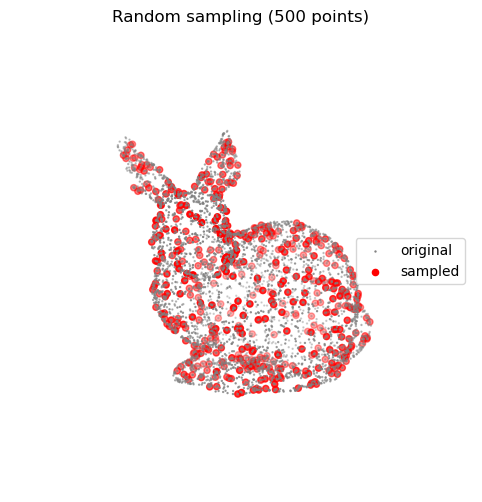

In [3]:
# Randomly sample 500 points from the bunny pointcloud
random_sampled_indices = random_sampling(points, 500)
random_sampled_points = points[random_sampled_indices]

# Visualize the original and randomly sampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(random_sampled_points[:, 0], random_sampled_points[:, 1],
            random_sampled_points[:, 2], 
            color='red', label="sampled")
ax.set_title(f"Random sampling ({len(random_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()

### Stride sampling

Stride Sampling, sometimes called uniform index sampling, is a simple and fast technique that works by **selecting points at regular index intervals**. Unlike random sampling, it is deterministic and therefore reproducible. Although it does not explicitly consider the spatial position of points, it may provide an approximately uniform spatial distribution when the point ordering reflects spatial locality, as is often the case for sequential acquisition systems such as RGB‑D cameras or linear laser scanners. However, when this assumption does not hold, stride sampling may produce uneven spatial coverage.

The implementation is straightforward and amounts to keeping every $n$-th point according to the initial ordering.

The implementation below uses NumPy's *slicing*, with an option to modify the initial ordering to add some randomness.

In [4]:
def stride_sampling(points, stride, shuffle=False):
    """Selects point indices at regular intervals."""
    
    N, _ = points.shape
    if not (isinstance(stride, int) and 1 <= stride < N):
        raise ValueError(
            "stride must be an int >= 1 and less than the number of points."
    )
    indices = np.arange(N)
    if shuffle: # optionally shuffle the indices to reduce ordering bias
        np.random.shuffle(indices)
    
    return indices[::stride]


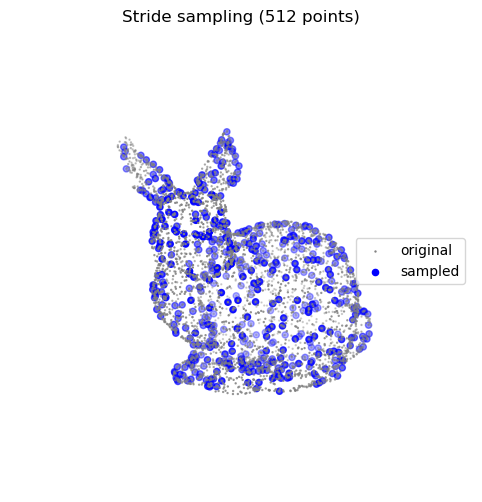

In [5]:
# Apply stride sampling to the bunny pointcloud
# using a stride of 8 to obtain a similar number of points as before
stride_sampled_indices = stride_sampling(points, stride=8)
stride_sampled_points = points[stride_sampled_indices]

# Visualize the original and stride-sampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(stride_sampled_points[:, 0], stride_sampled_points[:, 1],
            stride_sampled_points[:, 2], color='blue', label="sampled")
ax.set_title(f"Stride sampling ({len(stride_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()

## Spatial partitioning

Spatial partitioning divides three-dimensional space into regularly spaced cells that contain subsets of points (see the notebook on spatial indexing). The core idea is to **select one or more points from each cell**. By enforcing a more uniform spatial distribution of points, these techniques generally provide a more uniform spatial distribution than index-based methods and better preserve the overall shape of the pointcloud.

Spatial partitioning techniques are categorized according to the underlying spatial structure: a uniform grid with *voxel grid downsampling* and a hierarchical grid with *octree downsampling*. kd-trees are not considered here because their partitioning is irregular and directly related to geometric scale, making them less suitable for the subsampling tasks.

### Voxel grid downsampling

Voxel grid downsampling works by **dividing space into a regular grid of voxels and selecting one or more representative points per voxel**. The voxel size controls the resolution of the subsampled pointcloud: larger voxels produce fewer points, while smaller voxels preserve more detail. This makes voxel grid downsampling **particularly suitable when the desired resolution is known in advance**.

Once the voxel grid has been built, downsampling is efficient because each occupied voxel can be processed independently.

Several strategies can be used to select the representative point. Common choices include keeping the first point in the voxel, selecting a random point, or choosing the point closest to the voxel center. Choosing the point closest to the voxel center generally provides a more regular spatial distribution.

A custom voxel grid implementation based on a dictionary (hash map) is presented below, with options to keep either the first point in each voxel or the point closest to the voxel center.

In [6]:
class VoxelGrid:
    """Partition 3D space into voxels."""

    class Voxel:
        """Cubic voxel."""

        def __init__(self, center):
            self.center = center # center of the cube
            self.indices = []

    def __init__(self, points, voxel_size):
        
        self.points = points
        self.voxel_size = voxel_size
        self.voxels = {}
        self._build()

    def _build(self):
        """Create the voxel grid by filling cells with points."""
        
        for i, point in enumerate(self.points): 
            coords = self.voxel_coordinates(point)
            voxel = self.voxels.setdefault(
                coords,
                self.Voxel(center=(np.array(coords) + 0.5) * self.voxel_size)
            )
            voxel.indices.append(i)

    def voxel_coordinates(self, point):
        """Coordinates of a voxel for a given point"""
        return tuple(np.floor(point / self.voxel_size).astype(int))

    def sample_indices(self, closest_to_center=False):
        """Sample one index per voxel."""
        
        sampled_indices = []
        for voxel in self.voxels.values():
            if closest_to_center:
                # Find the point in the voxel closest to the voxel center
                points_in_voxel = self.points[voxel.indices]
                # Squared distances for efficiency
                distances = np.sum((points_in_voxel - voxel.center)**2, axis=1)
                closest_point_idx = np.argmin(distances)
                chosen_index = voxel.indices[closest_point_idx]
            else:
                chosen_index = voxel.indices[0]
            sampled_indices.append(chosen_index)
        
        return sampled_indices


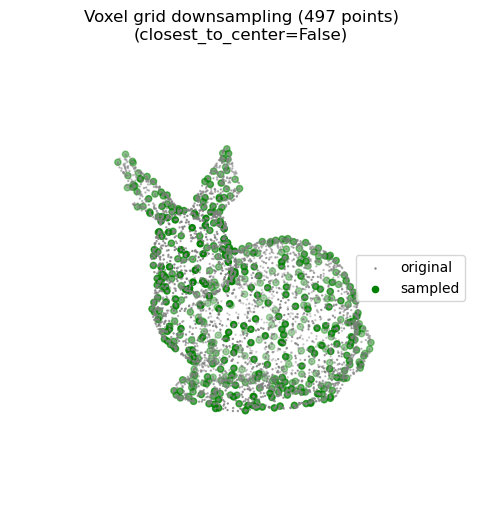

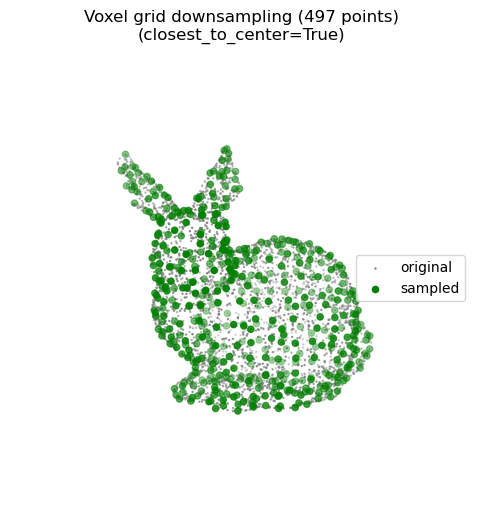

In [8]:
# Voxel grid downsampling
# using a voxel size of 12. to obtain a similar number of points as before
voxel_grid = VoxelGrid(points, voxel_size=12.) 
# Compare two representative-point selection strategies
for closest_to_center in [False, True]:
    sampled_indices = voxel_grid.sample_indices(closest_to_center)
    voxel_sampled_points = points[sampled_indices]

    # Visualize the original and voxel grid downsampled pointclouds
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
            color='grey', s=0.5, label='original')
    ax.scatter(voxel_sampled_points[:, 0], voxel_sampled_points[:, 1],
            voxel_sampled_points[:, 2], color='green', label="sampled")
    ax.set_title(f"Voxel grid downsampling ({len(voxel_sampled_points)}" + 
                 f" points)\n(closest_to_center={closest_to_center})")
    ax.legend(loc="right")
    ax.view_init(10, 60)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])
    plt.show()

### Octree downsampling

Octree downsampling works similarly to voxel grid downsampling but uses a hierarchical spatial subdivision instead of a regular grid. Regions containing many points are subdivided more finely, while sparse regions remain larger. This makes octree downsampling **well suited to pointclouds with highly non-uniform point densities or when the desired level of detail is not known in advance**.

Compared to voxel grids, octrees are more complex to build. However, once the octree has been constructed, different subsampling resolutions can be obtained by selecting different tree depths.

As with voxel grids, representative points may be chosen using simple strategies such as keeping the first point or selecting one at random or using geometry‑aware criteria such as proximity to the node center or centroid. Because the number of occupied nodes varies with depth, the final number of sampled points is not known in advance.

The custom octree implementation presented below selects the first point contained in each node at a given subdivision level.

In [9]:
class OcTree:
    """Partition 3D space by recursively subdividing it into eight octants."""
    
    class OctNode:
        """A node of our Octree or octant."""

        def __init__(self, depth, bound_min, bound_max, indices):

            self.depth = depth # Distance from the root
            self.bound_min = bound_min # Bottom-left corner
            self.bound_max = bound_max # Top-right corner
            self.indices = indices # Point indices
            self.children = [] # Leaf by default

        @property
        def is_leaf(self):
            """A terminal/leaf node does not have children."""
            return not len(self.children)

    def __init__(self, points, max_leaf_size=10, max_depth=10):

        self.points = points
        self.max_leaf_size = max_leaf_size
        self.max_depth = max_depth
        # Create root node
        bound_min = points.min(axis=0)
        bound_max = points.max(axis=0) + 1e-8 # slightky enlarge
        indices = np.arange(len(points), dtype=int)
        self.root = OcTree.OctNode(0, bound_min, bound_max, indices)
        # Recursively build the tree
        self._split_node(self.root)
    
    def _split_node(self, node):
        """Recursively split a node into eight subnodes/children."""

        # Do not split if node is already too small or if reached maximum depth
        if (len(node.indices) <= self.max_leaf_size 
            or node.depth >= self.max_depth):
            return
        # Compute the bounds of the eight candidate subnodes
        x_center, y_center, z_center = (node.bound_min + node.bound_max)/2
        x_min, y_min, z_min = node.bound_min
        x_max, y_max, z_max = node.bound_max
        new_bounds = [ 
            # South-West-Back
            (np.array([x_min, y_min, z_min]),
             np.array([x_center, y_center, z_center])),
            # North-West-Back
            (np.array([x_min, y_min, z_center]),
             np.array([x_center, y_center, z_max])),
            # North-East-Back
            (np.array([x_min, y_center, z_center]),
             np.array([x_center, y_max, z_max])),
            # South-East-Back
            (np.array([x_min, y_center, z_min]),
             np.array([x_center, y_max, z_center])),
            # South-West-Front
            (np.array([x_center, y_min, z_min]),
             np.array([x_max, y_center, z_center])),
            # North-West-Front
            (np.array([x_center, y_min, z_center]),
             np.array([x_max, y_center, z_max])),
            # North-East-Front
            (np.array([x_center, y_center, z_center]),
             np.array([x_max, y_max, z_max])),
            # South-East-Front
            (np.array([x_center, y_center, z_min]),
             np.array([x_max, y_max, z_center]))
        ]
        # Compute the node points falling into each subnode
        for (bound_min_new, bound_max_new) in new_bounds:
            in_subnode = np.logical_and(
                (self.points[node.indices] >= bound_min_new).all(axis=1), 
                (self.points[node.indices] < bound_max_new).all(axis=1)
            )
            # A subnode is created only if it contains some points
            if np.any(in_subnode):
                subnode = OcTree.OctNode(
                    node.depth + 1, # Increment depth
                    bound_min_new,
                    bound_max_new, 
                    node.indices[in_subnode]
                )
                node.children.append(subnode)
                # Recursively subdivide until leaves are small enough
                self._split_node(subnode)
        # Clear node indices after the node is split (only store for leaves)
        node.indices = []
    
    def sample_indices(self, subdivision_level):
        """Select the first point per node at a given subdivision level
         (if exceeding the octree depth, it just samples from leaves)."""

        sampled_indices = []
        # Explore the tree using breadth-first search
        queue = deque([self.root])
        while queue:
            node = queue.popleft()
            # Check if we reached the desired subdivision level
            if node.depth < subdivision_level and not node.is_leaf:
                # If not, continue exploring the tree
                queue.extend(node.children)
            else:
                # Continue down to a leaf node via the first child
                while not node.is_leaf:
                    node = node.children[0]
                # Sample the first points from this leaf node
                sampled_indices.append(node.indices[0])     

        return sampled_indices
    

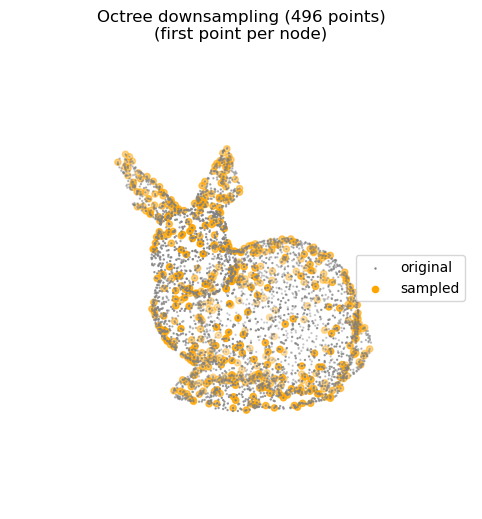

In [10]:
# Octree downsampling
# using a leaf size of 25 to obtain a similar number of points as before
octree = OcTree(points, max_leaf_size=25)
sampled_indices = octree.sample_indices(subdivision_level=4) 
octree_sampled_points = points[sampled_indices]

# Visualize the original and octree downsampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              color='grey', s=0.5, label='original')
ax.scatter(octree_sampled_points[:, 0], octree_sampled_points[:, 1],
              octree_sampled_points[:, 2], color='orange', label="sampled")
ax.set_title(f"Octree downsampling ({len(octree_sampled_points)} points)\n" +
             "(first point per node)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()

## Distance-based

Distance-based techniques rely on pairwise distances between points to guide subsampling. Spatial coverage and uniformity are preserved by avoiding the selection of points that are too close to each other.

### Farthest point sampling

Farthest point sampling (FPS) works by **iteratively selecting the point that is farthest from the points already sampled**. This produces a well-distributed subset that generally covers the original pointcloud more uniformly than random sampling. The main limitation of FPS is its computational cost, since distances must be updated after each new point is selected.

A common optimization avoids recomputing distances to all previously selected points. Instead, each point stores its current distance to the nearest sampled point. When a new point is selected, only this value needs to be updated. Implementations also typically use squared Euclidean distances to avoid unnecessary square-root computations. This results in the classical naïve implementation of FPS, which still requires updating distances for all remaining points at each iteration.

Several acceleration strategies have been proposed to reduce the number of distance evaluations. One simple approach uses spatial structures to restrict distance updates to points near the newly selected sample. Since only nearby points are likely to find a closer sampled point, many distance computations can be avoided. More advanced methods rely on techniques such as approximate nearest-neighbor search.

An implementation of FPS supporting both the naïve approach and a spatial-structure-based acceleration is proposed below. The implementation stores the distance between each point and its nearest sampled point. At each iteration, the point with the largest stored distance is selected, and the distances are updated accordingly. In the naïve version, all points are updated after each selection. The accelerated version updates distances only for points located within a radius equal to the current FPS distance.

In [11]:
def farthest_point_sampling(points, num_samples, neighbor_finder=None):
    """Return point indices selected with Farthest Point Sampling."""
    
    N, _ = points.shape
    if num_samples > N:
        raise ValueError("num_samples must be less than the number of points.")
    
    # In the naive implementation, all points are updated
    if neighbor_finder is None:
        neighbor_finder = lambda point, radius:  np.arange(N)
    # Randomly select the first point
    first_index = np.random.randint(N)
    sampled_indices = np.empty(num_samples, dtype=int)
    sampled_indices[0] = first_index
    first_point = points[sampled_indices[0]] # first sampled point
    # Initialize distances
    squared_distances = np.sum((points - first_point) ** 2, axis=1)
    squared_distances[first_index] = 0.
        
    for i in range(1, num_samples):
        # Select the farthest point
        farthest_index = np.argmax(squared_distances)
        sampled_indices[i] = farthest_index
        farthest_point = points[farthest_index]
        # Compute radius to find points that need distance updates
        farthest_squared_distance = squared_distances[farthest_index]
        radius = np.sqrt(farthest_squared_distance)
        neighbor_indices = neighbor_finder(farthest_point, radius)
        # Update distances to the last sampled point
        dist_to_last = np.sum(
            (points[neighbor_indices] - farthest_point)**2,
            axis=1
        )
        squared_distances[neighbor_indices] = np.minimum(
            squared_distances[neighbor_indices], dist_to_last
        )
        squared_distances[farthest_index] = 0.0
    
    return sampled_indices


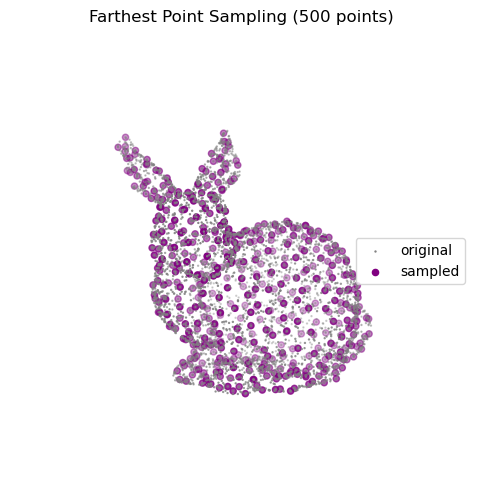

In [12]:
# Farthest Point Sampling with kd-tree acceleration
neighbor_finder = lambda point, radius: kdtree.query_ball_point(point, radius)
fps_sampled_indices = farthest_point_sampling(points, 500, neighbor_finder)
fps_sampled_points = points[fps_sampled_indices]

# Visualize the original and FPS sampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(fps_sampled_points[:, 0], fps_sampled_points[:, 1], 
           fps_sampled_points[:, 2], color='purple', label="sampled")
ax.set_title(f"Farthest Point Sampling ({len(fps_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()

### Radius sampling

Radius sampling (also called minimum‑distance sampling) **selects points such that no two retained points lie within a distance $r$ of each other**. It works by processing points one by one. When a point is selected, all other points within radius $r$ are excluded from further consideration. This guarantees a minimum spacing of at least $r$ between sampled points. For a fixed point ordering and radius, the result is deterministic.

Efficient implementation relies on spatial search structures to quickly identify neighbors within the radius $r$.

The implementation below relies on a kd‑tree for fast neighborhood searches and uses a Boolean mask to track selected points.

In [13]:
def radius_sampling(points, neighbor_finder):
    """Return point indices selected by radius sampling."""

    N, _ = points.shape   
    # Boolean mask keeping track of selected points
    selected = np.ones(N, dtype=bool)
    
    for ind in np.arange(N):
        # Skip this point if it has already been discarded
        if not selected[ind]:
            continue
        # Find neighbors of this point
        neighbors = neighbor_finder(points[ind])
        neighbors = np.array(neighbors)
        # Skip further steps if this point has no neighbors (and keep it)
        if not neighbors.size:
            continue
        # Check only neighbors that have not been processed yet
        mask = neighbors > ind
        if not np.any(mask):
            continue
        # Discard all relevant neighbors of this point
        selected[neighbors[mask]] = False
    
    return np.flatnonzero(selected)


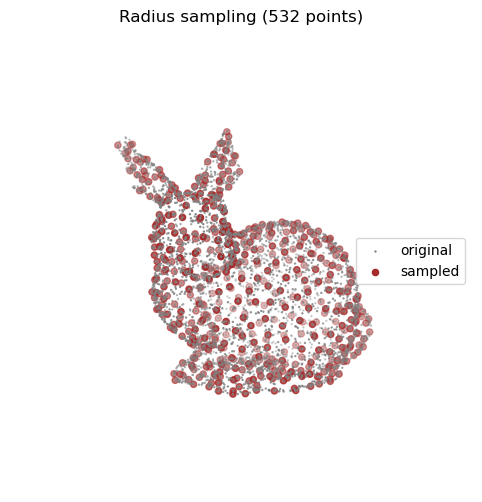

In [14]:
# Radius sampling using a greedy algorithm
# using a radius of 7.5 to obtain a similar number of points as before
neighbor_finder = lambda point: kdtree.query_ball_point(point, r=7.5)
radius_sampled_indices = radius_sampling(points, neighbor_finder)
radius_sampled_points = points[radius_sampled_indices]

# Visualize the original and radius sampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(radius_sampled_points[:, 0], radius_sampled_points[:, 1],
           radius_sampled_points[:, 2], color='brown', label="sampled")
ax.set_title(f"Radius sampling ({len(radius_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()

### Poisson-disk sample elimination

Poisson-disk sample elimination generates a well-distributed subset by **iteratively removing points from an initially dense pointcloud**. Each point is assigned a weight based on the density of its neighborhood, with nearby neighbors contributing more than distant ones. At each iteration, the point with the largest weight is removed and the weights of neighboring points are updated. The process continues until the desired number of points remains, producing a distribution that approximates Poisson-disk sampling without generating new points.

The implementation below follows this elimination strategy and uses a kd-tree to efficiently identify neighboring points. This approach is similar in spirit to the `sample_points_poisson_disk` function provided by `Open3D`, which is based on the sample elimination method proposed by Yuksel \cite{yuksel2015sample}.

In [ ]:
def poisson_disk_elimination(points, num_samples, neighbor_finder, radius):
    """Poisson-disk sample elimination."""

    N, _ = points.shape
    if num_samples >= N:
        raise ValueError("num_samples must be less than the number of points.")

    # Neighborhoods for all points
    neighbor_inds = neighbor_finder(points)
    # Pairwise contributions and initial weights
    contributions = []
    weights = np.zeros(N)
    for i, neighbors in enumerate(neighbor_inds):
        neighbors = np.asarray(neighbors)
        neighbors = neighbors[neighbors != i]
        if neighbors.size:
            distances = np.linalg.norm(points[neighbors] - points[i], axis=1)
            contrib = np.maximum(0.0, 1.0 - distances / radius)
        else:
            contrib = np.empty(0)
        contributions.append((neighbors, contrib))
        weights[i] = contrib.sum()

    active = np.ones(N, dtype=bool)
    while np.sum(active) > num_samples:
        # Remove the most crowded point
        active_weights = np.where(active, weights, -np.inf)
        remove_idx = np.argmax(active_weights)
        active[remove_idx] = False
        # Update neighboring weights
        neighbors, contrib = contributions[remove_idx]
        for j, c in zip(neighbors, contrib):
            if active[j]:
                weights[j] -= c

    return np.flatnonzero(active)

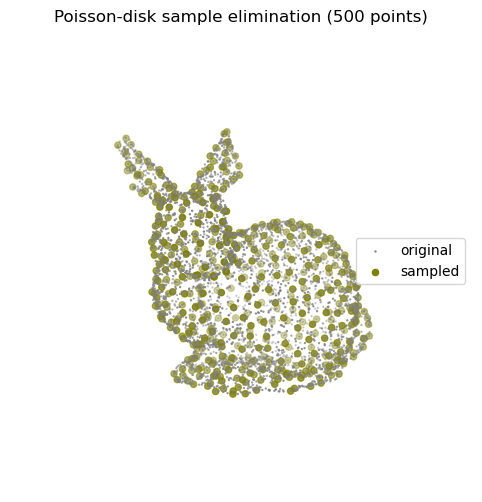

In [21]:
# Poisson-disk sample elimination
neighbor_finder = lambda point: kdtree.query_ball_point(point, r=10.)
poisson_sampled_indices = poisson_disk_elimination(
    points, 
    500, # num_samples
    neighbor_finder,
    10. # radius
) 
poisson_sampled_points = points[poisson_sampled_indices]

# Visualize the original and Poisson-disk sampled points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(poisson_sampled_points[:, 0], poisson_sampled_points[:, 1],
           poisson_sampled_points[:, 2], color='olive', label="sampled")
ax.set_title(f"Poisson-disk sample elimination "
             f"({len(poisson_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
ax.set_box_aspect([1, 1, 1])
plt.show()


## Quick comparison

Below is a table summarizing all subsampling techniques discussed in this notebook. Time complexity uses the "big-O notation", where $n$ is the initial number of points and $k$ the desired sample size. The cost of building spatial structures for acceleration is not included in the table but discussed below. $m$ is the total number of voxel cells or octree cells at a given depth.

| Technique       | Category | Deterministic | Count control | Uniformity | Time complexity  |
|:----------------|:---------|:--------------|:--------------|:-----------|:-----------------|
| Random          | Index    | No            | Exact         | Low        | $O(k)$ to $O(n)$ |
| Stride          | Index    | Yes           | Exact         | Low        | $O(k)$ to $O(n)$ |
| Voxel Grid      | Spatial  | Yes           | Approximate   | Medium     | $O(m)$ to $O(n)$ |
| Octree          | Spatial  | Yes           | Approximate   | Medium     | $O(m)$ to $O(n)$ |
| FPS (naïve)     | Distance | Yes           | Exact         | High       | $O(n k)$         |
| Radius          | Distance | Yes           | Approximate   | Medium     | $O(n \log n)$    |
| Poisson (naïve) | Distance | Yes           | Exact         | High       | $O(n^2)$         |

Index‑based techniques are extremely fast. *Random sampling* runs in linear time either in $k$ when drawing $k$ random indices, or in $n$ when scanning the full array with Bernoulli probability or after generating a random permutation. *Stride sampling* behaves similarly, with a cost proportional to $k$ when using direct indexing, or $n$ when scanning and retaining every fixed step.

Spatial partitioning methods remain efficient once their structures are built. *Voxel grids* are constructed in linear time, while *octrees* require linear to linearithmic time depending on tree balance. Sampling then simply extracts one representative per voxel or octree leaf, linear time in $m$ occupied cells, or up to linear time in $n$ when selecting the point closest to a cell center.

Distance‑based techniques are more expensive. Naïve *Farthest Point Sampling* updates distances to all $n$ points at each of the $k$ iterations, giving linear time in both $n$ and $k$. *Radius sampling* uses spatial queries to enforce a minimum spacing, leading to linearithmic time with KD‑trees or grids. The computational cost of *Poisson-disk sample elimination* depends on how point weights are updated and maintained during the elimination process. The simplified implementation presented in this notebook repeatedly searches for the point with the highest weight, resulting in quadratic complexity. More advanced implementations use priority queues and efficient neighborhood updates to reduce the cost considerably.


## Wrapping up

You should now have a better grasp of 3D pointcloud subsampling and its role within the larger processing pipeline. Raw pointclouds often contain millions of points, far more than needed for tasks such as registration, surface reconstruction, semantic segmentation, or real‑time inference. Subsampling is therefore a crucial early step, as it reduces redundancy, controls density, and improves computational tractability while attempting to preserve geometric structure.

Depending on the application, one may choose extremely fast index‑based techniques, spatially aware voxel and octree reductions, or more sophisticated distance‑based techniques that maximize uniformity. No single technique is universally optimal and each represents a specific trade‑off between speed, regularity, determinism, and the ability to target an exact number of samples. Understanding these tradeoffs makes it easier to choose the right technique for downstream algorithms, ensuring that subsequent stages operate efficiently without sacrificing essential geometric information.